<h1 style="color:#001069ff; border-bottom:3px solid #242f6dff; padding-bottom:8px;">🚀 Detecção de Objetos com YOLOS-Small</h1>

Bem-vindo! Neste notebook, usaremos o modelo **YOLOS (You Only Look at One Sequence)** do Hugging Face para a detecção de objetos em imagens. Tomamos como base a detecção original e configuramos para usar a pasta de imagens local.

<h3 style="color:#242f6d;">🧪 Informações do Modelo:</h3>

- **Nome do Modelo** : `hustvl/yolos-small`
- **Arquitetura**: Vision Transformer (ViT)
- **Fonte**: [Hugging Face](https://huggingface.co/hustvl/yolos-small)

In [1]:
import os
import torch
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
from transformers import AutoImageProcessor, AutoModelForObjectDetection

# Configurar dispositivo (GPU se disponível, senão CPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando o dispositivo: {device}")

c:\Users\joao_\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Usando o dispositivo: cpu


<br>
<h2 style="color:#001069;">🛠 Configuração do Modelo e Processador</h2>

Vamos carregar o modelo pré-treinado e seu processador de imagens correspondente.

In [2]:
model_name = "hustvl/yolos-small"

# Carregar o processador e o modelo da Hugging Face
processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModelForObjectDetection.from_pretrained(model_name).to(device)

c:\Users\joao_\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:140: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\joao_\.cache\huggingface\hub\models--hustvl--yolos-small. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


<br>
<h2 style="color:#001069;">🖼 Processando Imagens</h2>

Vamos definir uma função para realizar a detecção de objetos e plotar as caixas delimitadoras (bounding boxes) sobre a imagem.

In [10]:
def detect_objects(image_path, threshold=0.4):
    # Carregar a imagem
    image = Image.open(image_path).convert("RGB")
    
    # Preparar a imagem para o modelo
    inputs = processor(images=image, return_tensors="pt").to(device)
    
    # Passagem direta (Forward pass)
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Pós-processar as detecções em cima da imagem original
    target_sizes = torch.tensor([image.size[::-1]]).to(device)
    results = processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=threshold)[0]
    
    return image, results

def plot_results(image, results):
    plt.figure(figsize=(16, 12))
    plt.imshow(image)
    ax = plt.gca()
    
    # Escolher lista de cores para desenhar
    colors = plt.cm.hsv(torch.linspace(0, 1, 91)).tolist()
    
    for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
        box = [round(i, 2) for i in box.tolist()]
        x, y, x2, y2 = box
        
        label_idx = label.item()
        color = colors[label_idx % len(colors)]
        
        # Desenhar caixa delimitadora
        rect = plt.Rectangle((x, y), x2 - x, y2 - y, fill=False, color=color, linewidth=3)
        ax.add_patch(rect)
        
        # Anotar rótulo e pontuação
        label_name = model.config.id2label[label_idx]
        ax.text(x, y, f"{label_name}: {score:.2f}", fontsize=15, 
                bbox=dict(facecolor=color, alpha=0.5, edgecolor='none', boxstyle='round,pad=0.2'))
    
    plt.axis("off")
    plt.tight_layout()
    plt.show()

<br>
<h2 style="color:#001069;">🧪 Executando a Inferência nas Imagens</h2>

Por fim, iteramos por todas as imagens do diretório `imagens` e fazemos a predição para cada uma delas.


Processando a imagem: bird.jpg...
{'scores': tensor([0.9999, 0.4527]), 'labels': tensor([16, 15]), 'boxes': tensor([[ 4.9465e+02,  2.8158e+02,  2.8844e+03,  2.4794e+03],
        [-2.4307e+00,  1.7051e+03,  4.3832e+03,  2.8627e+03]])}


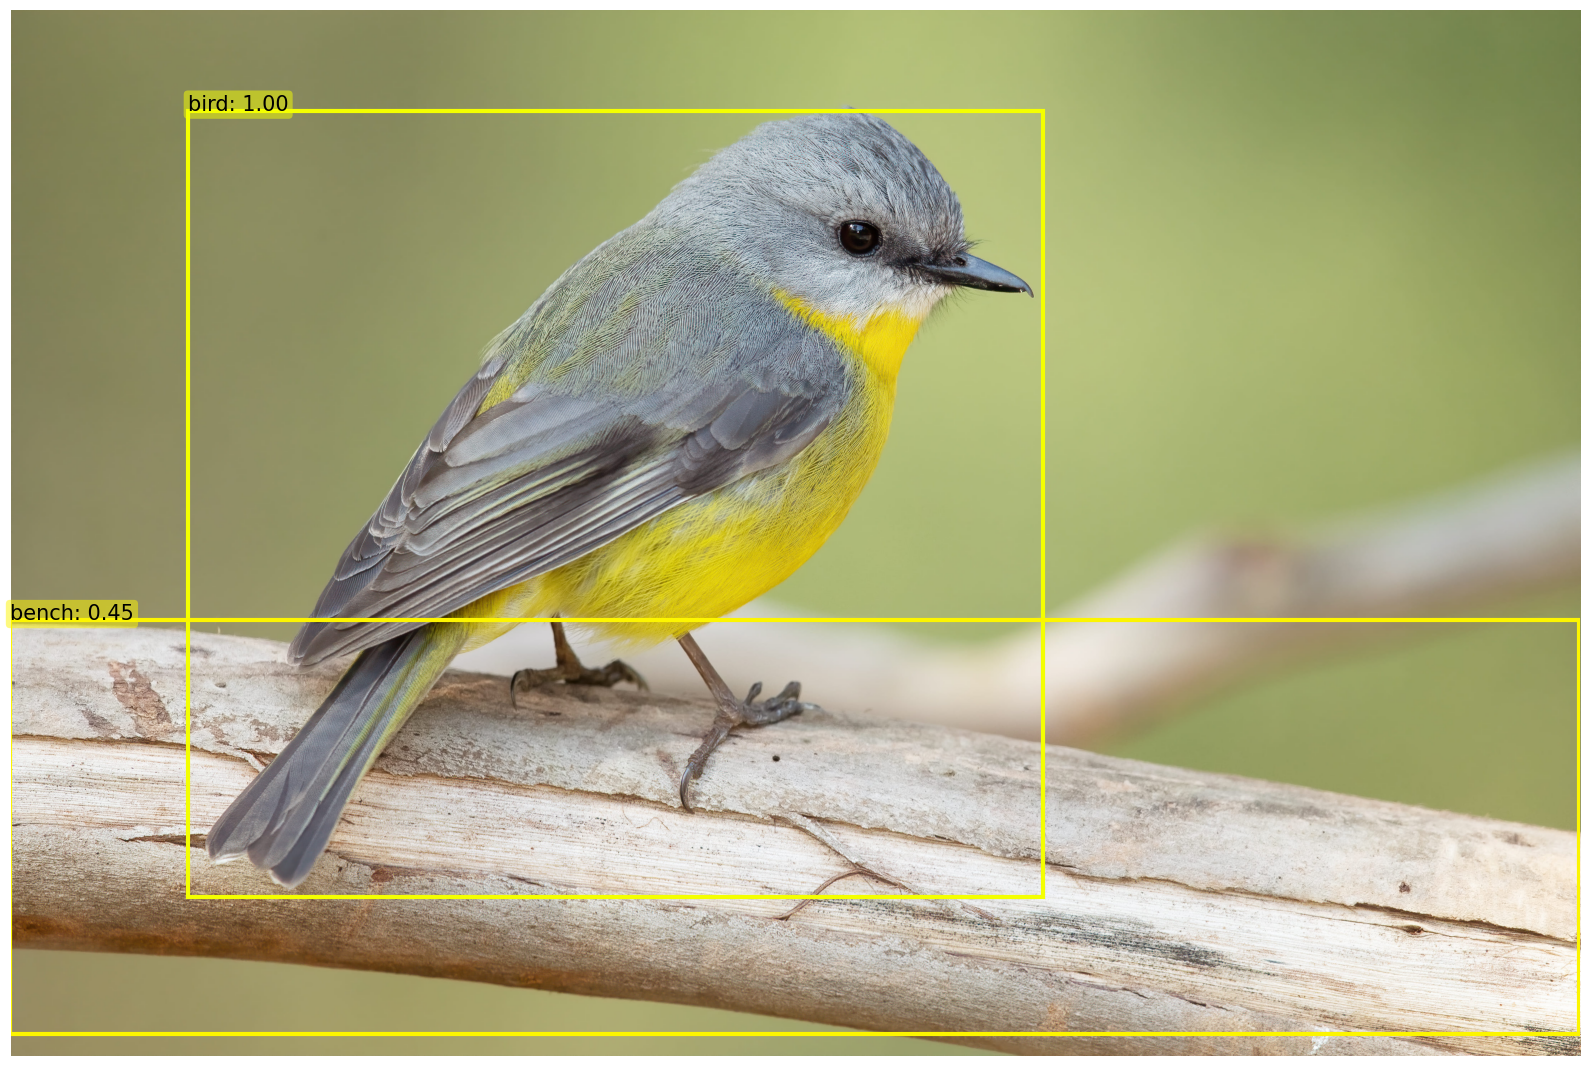


Processando a imagem: cats_dog.png...
{'scores': tensor([0.9990, 0.9946, 0.6141, 0.7866, 0.7949]), 'labels': tensor([17, 18, 65, 17, 65]), 'boxes': tensor([[ 6.3728e+02,  1.3484e+02,  8.5492e+02,  4.5646e+02],
        [ 2.4069e+02,  1.1352e+02,  7.6325e+02,  5.1251e+02],
        [-6.3777e-03,  2.8732e+02,  9.9997e+02,  5.5599e+02],
        [ 5.8720e+01,  2.4111e+02,  3.9242e+02,  4.9242e+02],
        [-6.7472e-02,  1.8438e+02,  9.9992e+02,  5.5541e+02]])}


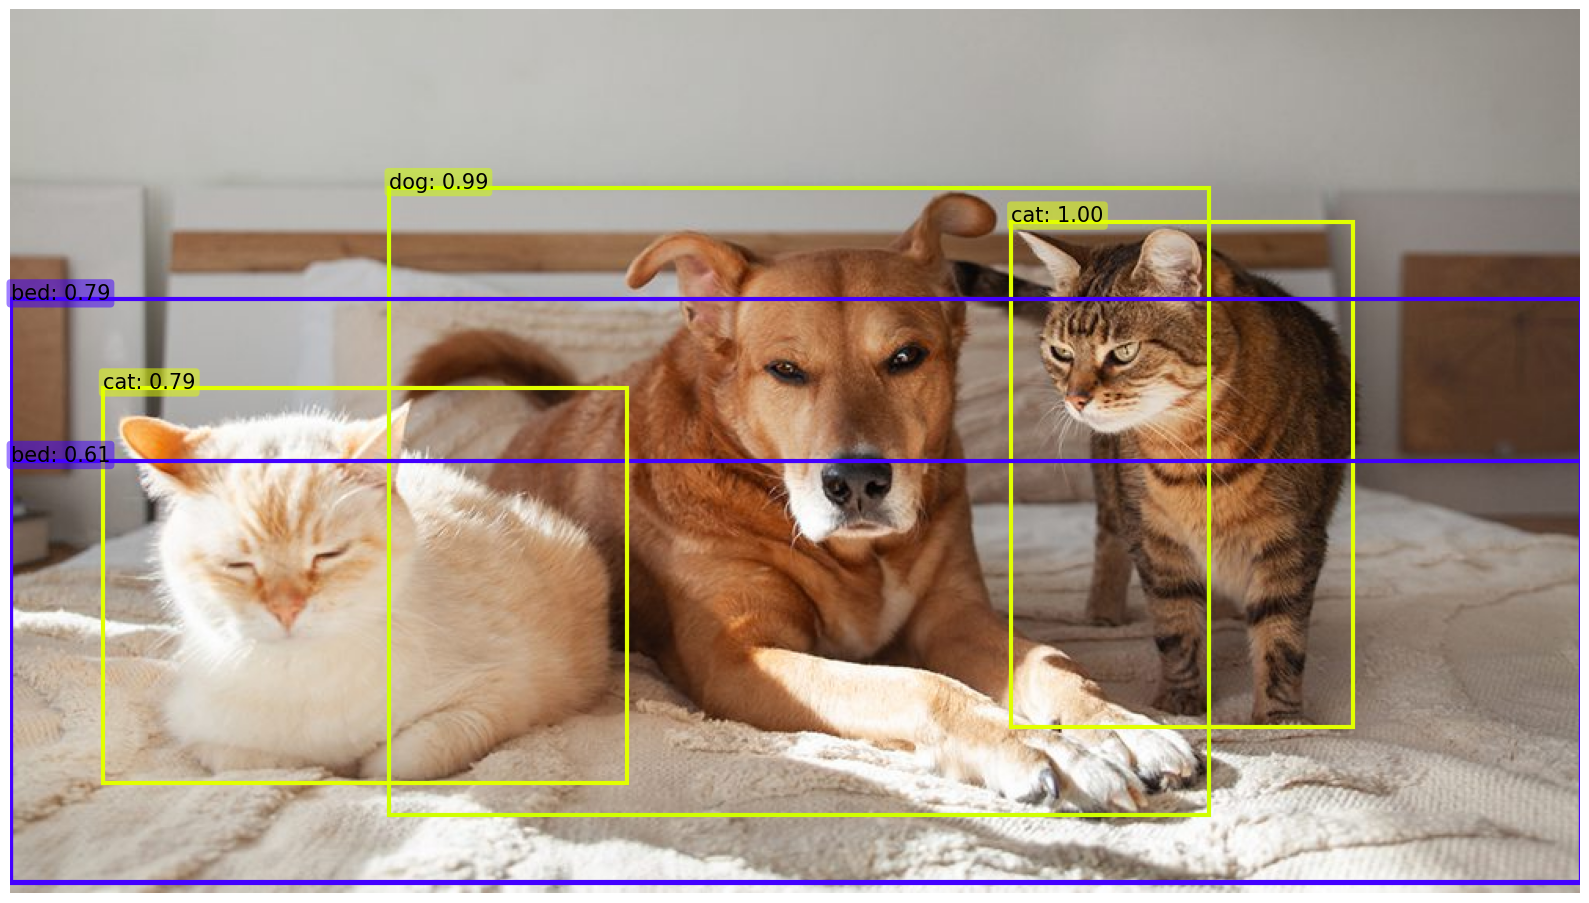


Processando a imagem: kitchen.png...
{'scores': tensor([0.4889, 0.5035, 0.9394, 0.4623, 0.4693, 0.4883, 0.4485, 0.4577, 0.4364,
        0.5391, 0.8149, 0.9683, 0.7631, 0.9183, 0.6476, 0.9306, 0.9507, 0.5172,
        0.8431, 0.5822, 0.9437, 0.4076, 0.7570]), 'labels': tensor([44, 51, 86, 86, 86, 44, 86, 55, 86, 50, 64, 86, 64, 44, 51, 64, 79, 86,
        82, 51, 51, 55, 64]), 'boxes': tensor([[ 2.5590e+02,  2.8491e+02,  2.9240e+02,  3.6657e+02],
        [ 5.5945e+02,  3.3189e+02,  6.3065e+02,  3.6494e+02],
        [ 1.0158e+02,  2.6728e+02,  1.4129e+02,  3.6453e+02],
        [ 9.9239e+01,  2.6785e+02,  1.3594e+02,  3.5978e+02],
        [ 6.5801e+02,  3.2799e+02,  7.0490e+02,  3.6951e+02],
        [ 2.7664e+02,  3.1673e+02,  2.9985e+02,  3.7010e+02],
        [ 5.0062e-03,  7.2478e+01,  2.7157e+01,  1.1444e+02],
        [ 3.0145e+02,  2.3473e+02,  3.1996e+02,  2.5641e+02],
        [ 6.5855e+02,  3.3293e+02,  7.0678e+02,  3.6832e+02],
        [ 3.2733e+02,  2.5599e+02,  3.5173e+02,  3.109

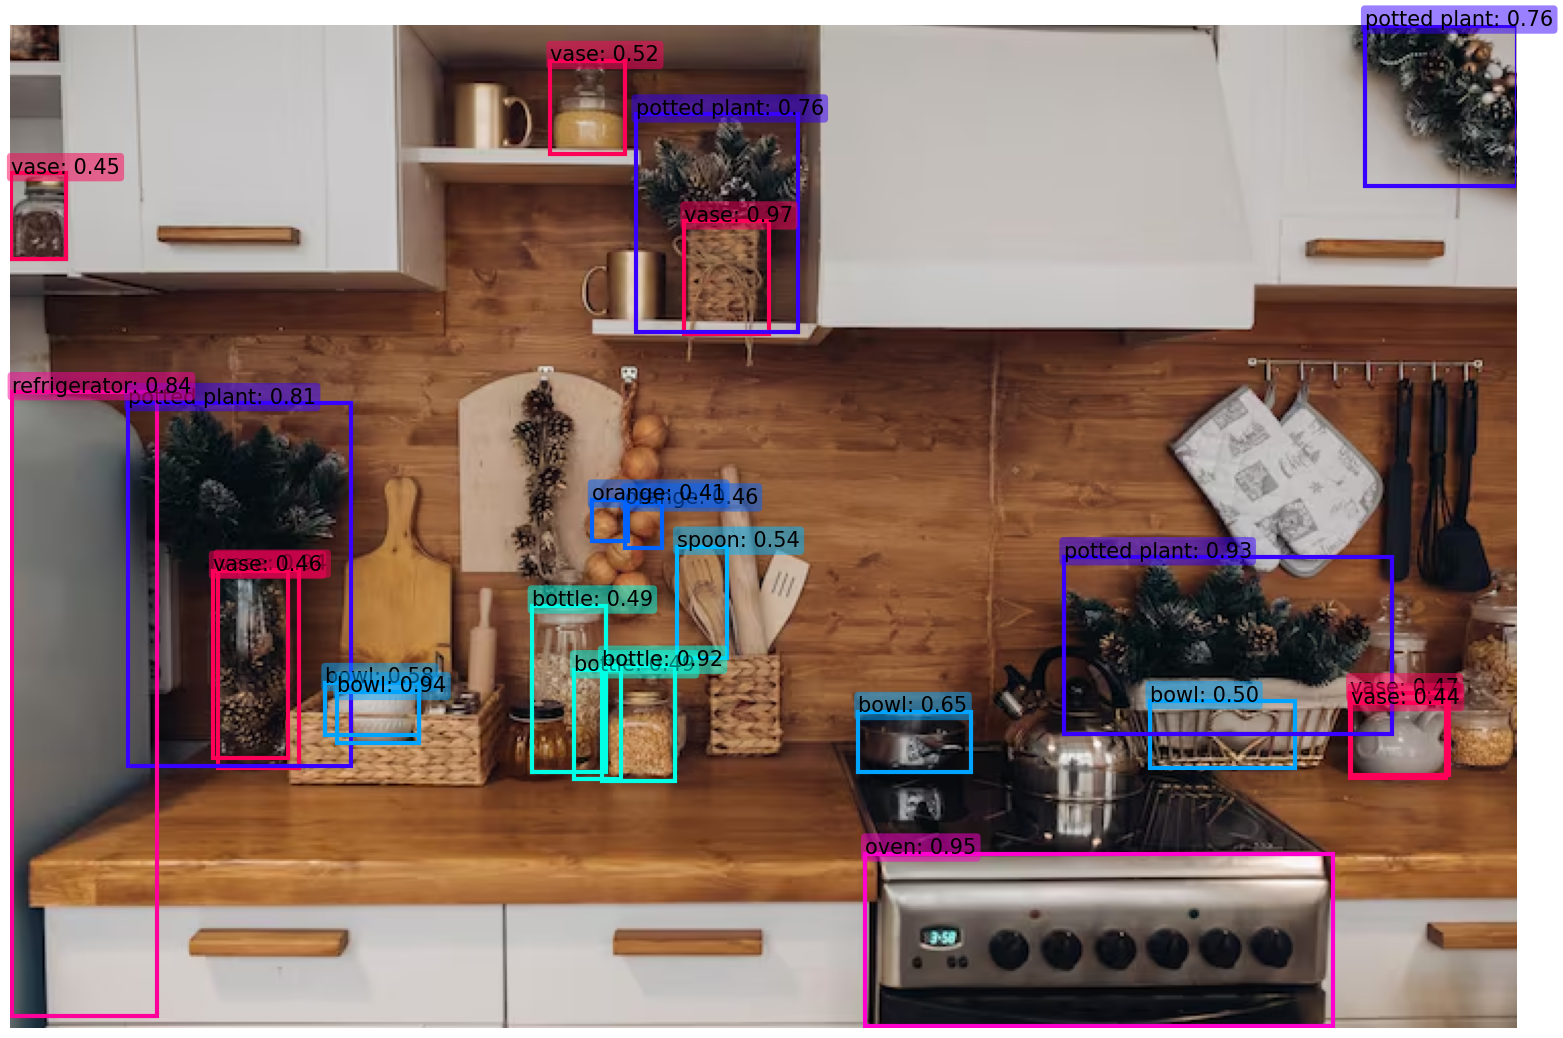


Processando a imagem: pizza.png...
{'scores': tensor([0.4863, 0.7767, 0.4272, 0.5167, 0.5997, 0.9055, 0.4700, 0.8763, 0.8141,
        0.9843, 0.6616, 0.5971]), 'labels': tensor([59, 59, 59, 59, 59, 59, 59, 59, 59, 59, 59, 59]), 'boxes': tensor([[   5.4979,  187.1549,  535.9073,  856.2231],
        [ 523.9216,  438.8962, 1019.3583,  789.5645],
        [ 268.2867,  419.6172, 1021.7637,  890.4398],
        [   7.7795,  134.6176,  792.6373,  869.7682],
        [ 540.5588,  216.6687, 1021.3561,  796.4653],
        [ 267.0289,  458.1334,  887.6635,  925.9318],
        [ 266.2147,  218.2950, 1022.0155,  900.2885],
        [   9.6022,  121.2170, 1021.2366,  920.0447],
        [   5.4816,  186.3620,  506.9989,  475.8358],
        [  13.7597,  432.3777,  525.2137,  866.5151],
        [ 296.8337,  111.6133,  790.4683,  469.4933],
        [ 295.7573,  113.1563,  799.8717,  470.5969]])}


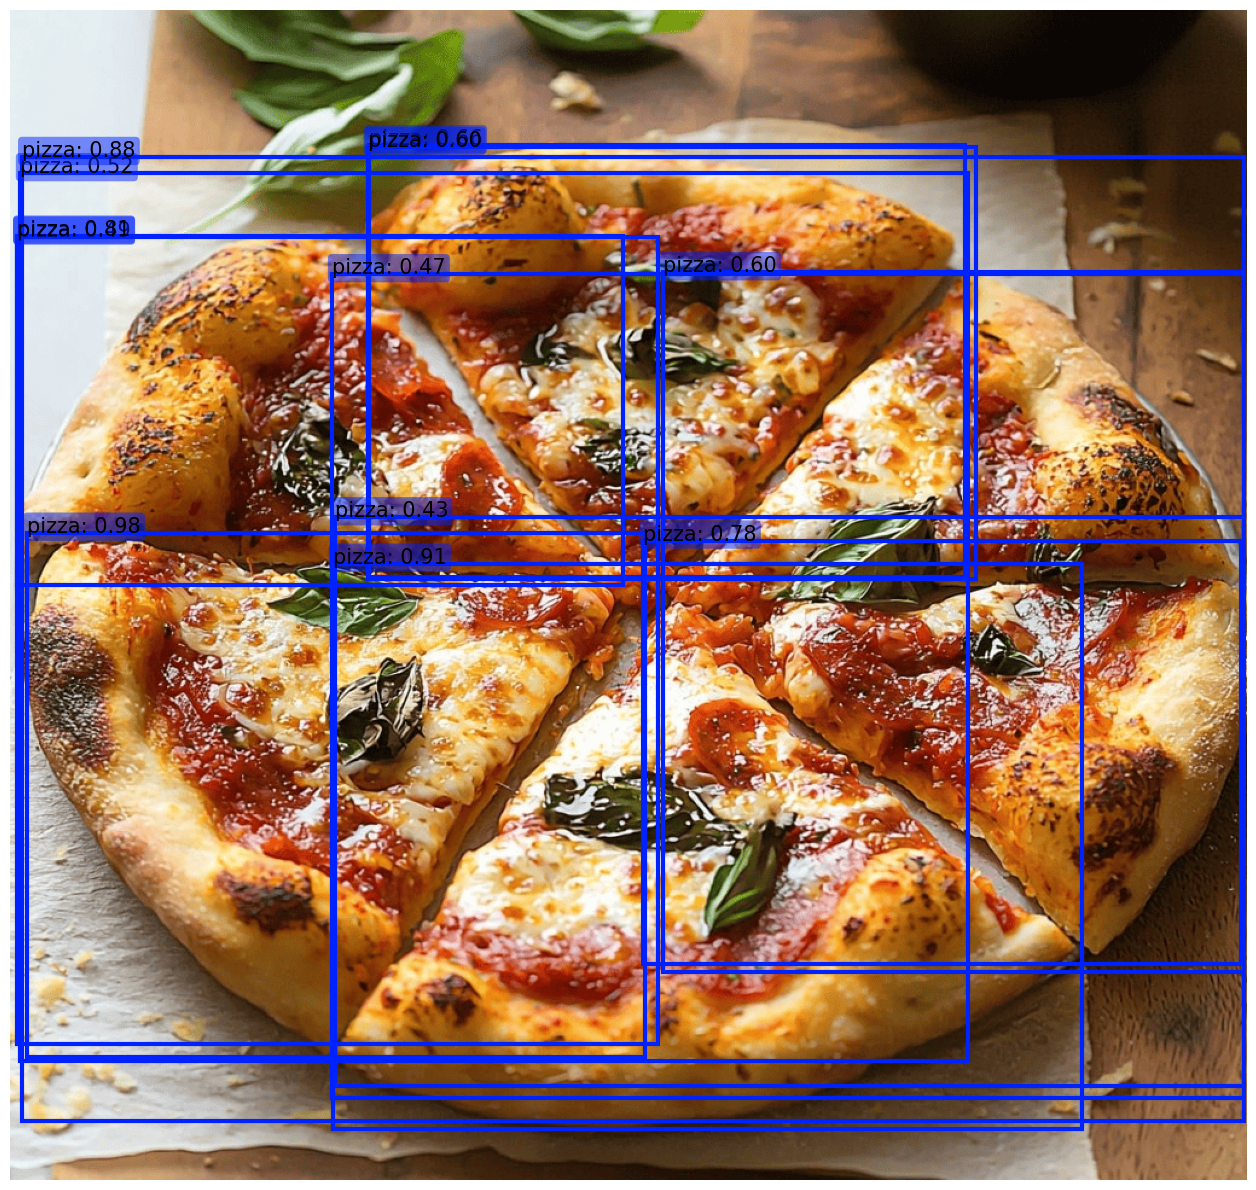

In [11]:
# Caminho relativo para a pasta 'imagens'
image_dir = "../imagens"

if not os.path.exists(image_dir):
    print(f"Diretório não encontrado: {image_dir}")
else:
    for img_name in os.listdir(image_dir):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(image_dir, img_name)
            print(f"\nProcessando a imagem: {img_name}...")
            
            # Detectar os objetos
            image, results = detect_objects(img_path, threshold=0.4)
            
            print(results)
            
            # Visualizar resultados plotados
            plot_results(image, results)